<a href="https://colab.research.google.com/github/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-2-distribuciones-y-analisis-de-datos/u4_ejemplos_analisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>


# Unidad 4 — Análisis de datos, en ejemplos

**Asignatura E8102 · Exploración de datos**

Este notebook acompaña al apunte de la unidad 4. No agrega teoría: toma el relevamiento de hogares
del T8001, el mismo de las tres unidades anteriores, y deja armar sus series, mover sus medidas y
dibujar sus cinco gráficos. Cada bloque dice a qué sección corresponde y qué conviene mirar.

Se lee el apunte primero y se juega con esto después.


## Cómo se usa

Antes de tocar nada: `Archivo` → `Guardar una copia en Drive`. Si no, los cambios se pierden.

Este notebook no pide escribir código. Cada bloque tiene un **formulario** con deslizadores y
listas desplegables. Se mueve un valor y el gráfico se vuelve a dibujar solo.

Tres pasos:

1. Ejecutar todo una vez: `Entorno de ejecución` → `Ejecutar todo`. Tarda unos segundos y deja
   listas las herramientas y los datos.
2. Bajar hasta un bloque, leer el resumen y mover los parámetros del formulario. La celda se
   ejecuta sola con cada cambio.
3. Si un formulario no reacciona, hacer clic adentro y apretar `Shift + Enter`, o volver al paso 1.

El código de cada formulario está oculto a propósito. Si te da curiosidad, `Mostrar código` lo
despliega, pero nada de este notebook requiere leerlo.


## Preparación

Dos celdas. La primera carga las herramientas y la paleta de colores. La segunda carga el
relevamiento de hogares del T8001, que los dos apuntes usan como ejemplo con datos reales.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Polygon, Rectangle
from cycler import cycler
from fractions import Fraction
from io import StringIO
import scipy
from scipy import stats

# La paleta de las ilustraciones del apunte, para que los gráficos se vean como el mismo material.
CREMA, TEAL, TEAL_PALIDO, MOSTAZA, CORAL, TINTA = (
    "#FEF8EF", "#61A9A1", "#D0E5DE", "#EEA92F", "#F07C52", "#32435D")

plt.rcParams.update({
    "figure.facecolor": CREMA, "axes.facecolor": CREMA, "savefig.facecolor": CREMA,
    "axes.edgecolor": TINTA, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": cycler(color=[TEAL, CORAL, MOSTAZA, TINTA]),
    "axes.grid": True, "grid.color": TEAL_PALIDO, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "figure.figsize": (9, 4.5), "figure.dpi": 100,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "font.size": 11,
})


def num(x, decimales=4):
    """Número con coma decimal, como en el apunte."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "—"
    if abs(x) < 0.5 * 10 ** -decimales:
        x = 0.0   # evita el "-0,0000"
    return f"{x:,.{decimales}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def frac(k, n):
    """'k/n = 0,xxxx' con la fracción sin simplificar, que es como la escribe el apunte."""
    return f"{k}/{n} = {num(k / n)}"


print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", scipy.__version__, "| todo listo")


ORDEN_SATISFACCION = ["mala", "regular", "buena"]


def serie_frecuencia(serie, orden=None):
    """La tabla de cuatro columnas de la sección 2.2: fᵢ, frᵢ, Fᵢ y Frᵢ."""
    conteo = serie.dropna().value_counts()
    conteo = conteo.reindex(orden).dropna().astype(int) if orden else conteo.sort_index()
    total = int(conteo.sum())
    return pd.DataFrame({"fᵢ": conteo.to_numpy(),
                         "frᵢ": conteo.to_numpy() / total,
                         "Fᵢ": np.cumsum(conteo.to_numpy()),
                         "Frᵢ": np.cumsum(conteo.to_numpy()) / total}, index=conteo.index), total


def cuartil_formula(x, k):
    """El cuartil por la fórmula clásica k(n+1)/4, interpolando si la posición no es entera."""
    v = np.sort(np.asarray(x, dtype=float))
    n = len(v)
    posicion = k * (n + 1) / 4
    if posicion <= 1:
        return v[0]
    if posicion >= n:
        return v[-1]
    bajo = int(np.floor(posicion))
    return v[bajo - 1] + (posicion - bajo) * (v[bajo] - v[bajo - 1])


def limites_ric(x, factor=1.5):
    """Los dos límites de la regla de Tukey, con los cuartiles de pandas y numpy."""
    q1, q3 = np.percentile(x, [25, 75])
    ric = q3 - q1
    return q1 - factor * ric, q3 + factor * ric, q1, q3, ric


def descriptivo(x):
    """El análisis completo de la sección 8, sobre una variable cuantitativa."""
    v = np.asarray(x, dtype=float)
    n = len(v)
    bajo, alto, q1, q3, ric = limites_ric(v)
    modos = pd.Series(v).mode()
    repite = pd.Series(v).value_counts().max() > 1
    return {
        "casos válidos": n,
        "mínimo": v.min(), "máximo": v.max(),
        "media": v.mean(), "mediana": float(np.median(v)),
        "modo": float(modos.iloc[0]) if repite else np.nan,
        "Q₁": q1, "Q₃": q3,
        "desvío standard (n)": v.std(ddof=0), "desvío standard (n − 1)": v.std(ddof=1),
        "RIC": ric, "CV (%)": 100 * v.std(ddof=0) / v.mean() if v.mean() else np.nan,
        "asimetría α₃": stats.skew(v), "kurtosis α₄": stats.kurtosis(v, fisher=False),
        "límite inferior 1,5 × RIC": bajo, "límite superior 1,5 × RIC": alto,
    }


def recta_de_puntos(ax, valores, color=TEAL, altura=0.0, tamano=70):
    """Los datos como marcas sobre una recta, que es como los dibuja el apunte."""
    ax.plot(valores, np.full(len(valores), altura), "o", color=color, markersize=np.sqrt(tamano),
            alpha=0.75, clip_on=False)


def caja(ax, grupos, etiquetas):
    """Un boxplot horizontal con la paleta del apunte.

    La orientación cambió de nombre en matplotlib 3.10, y Colab puede traer cualquiera de las dos."""
    estilo = dict(patch_artist=True, widths=0.55,
                  boxprops=dict(facecolor=TEAL_PALIDO, edgecolor=TINTA),
                  medianprops=dict(color=CORAL, linewidth=2.2),
                  whiskerprops=dict(color=TINTA), capprops=dict(color=TINTA),
                  flierprops=dict(marker="o", markerfacecolor=CORAL, markeredgecolor=CORAL, markersize=7))
    version = tuple(int(parte) for parte in plt.matplotlib.__version__.split(".")[:2])
    estilo["orientation" if version >= (3, 10) else "vert"] = "horizontal" if version >= (3, 10) else False
    return ax.boxplot(grupos, tick_labels=etiquetas, **estilo)


def separar_servicios(serie):
    """La columna servicios trae varias categorías por hogar, separadas por punto y coma."""
    return serie.dropna().str.split(";").explode().str.strip()


numpy 2.3.2 | pandas 2.3.2 | scipy 1.17.1 | todo listo


El relevamiento va adentro del notebook, como texto, así que no hace falta conexión. Son **45
visitas a 37 hogares**: ocho hogares recibieron una segunda visita. El apunte de la unidad 2 fija la
regla, la primera visita de cada hogar, y acá se usa la misma en las dos unidades. La copia
publicada está en
[`datos/relevamiento_plano.csv`](https://github.com/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-1-probabilidad-y-variables-aleatorias/datos/relevamiento_plano.csv).


In [2]:
CSV = """id_hogar,localidad,provincia,fecha_visita,encuestador_legajo,encuestador_nombre,encuestador_telefono,personas,ingreso,cobertura_salud,satisfaccion,servicios
1,Ramallo,Buenos Aires,2025-03-14,E04,"Sosa, Diego",3407-419854,3,185000,si,buena,agua;luz;gas
1,Ramallo,Buenos Aires,2025-06-12,E04,"Sosa, Diego",3407-419854,4,201000,si,buena,agua;luz;gas
2,Córdoba,Córdoba,2025-03-15,E02,"Ledesma, Julio",351-4778120,5,240500,no,regular,agua;luz
3,Concepción,Tucumán,2025-03-15,E03,"Bianchi, Ana",381-4551907,2,,,,luz
4,Ramallo,Buenos Aires,2025-03-16,E01,"Rivas, Marta",3407-412233,4,198000,si,buena,agua;luz;gas
5,Ramallo,Buenos Aires,2025-03-16,E04,"Sosa, Diego",3407-419854,1,120000,,,luz
7,Córdoba,Córdoba,2025-03-17,E04,"Sosa, Diego",3407-419854,6,310000,no,mala,agua;luz;gas;cloacas
7,Córdoba,Córdoba,2025-06-13,E04,"Sosa, Diego",3407-419854,6,325000,no,regular,agua;luz;gas;cloacas
8,Concepción,Tucumán,2025-03-17,E03,"Bianchi, Ana",381-4551907,3,175000,si,regular,agua;luz
9,Ramallo,Buenos Aires,2025-03-18,E04,"Sosa, Diego",3407-419854,2,,no,mala,luz;gas
10,Córdoba,Córdoba,2025-03-19,E02,"Ledesma, Julio",351-4778120,4,205000,,,agua;luz;gas
11,Concepción,Tucumán,2025-03-20,E03,"Bianchi, Ana",381-4551907,7,260000,si,buena,agua;luz;gas;cloacas
11,Concepción,Tucumán,2025-06-13,E03,"Bianchi, Ana",381-4551907,7,268000,si,buena,agua;luz;gas;cloacas
13,Ramallo,Buenos Aires,2025-03-20,E04,"Sosa, Diego",3407-419854,3,190000,,,agua;luz
14,Córdoba,Córdoba,2025-03-21,E02,"Ledesma, Julio",351-4778120,2,168000,no,regular,agua
15,Ramallo,Buenos Aires,2025-03-21,E04,"Sosa, Diego",3407-419854,3,172000,si,regular,agua;luz;gas
16,Concepción,Tucumán,2025-03-24,E03,"Bianchi, Ana",381-4551907,4,195000,no,buena,agua;luz
17,Córdoba,Córdoba,2025-03-24,E04,"Sosa, Diego",3407-419854,2,210000,si,regular,agua;luz;gas
18,Córdoba,Córdoba,2025-03-25,E02,"Ledesma, Julio",351-4778120,5,155000,,,luz
19,Ramallo,Buenos Aires,2025-03-25,E04,"Sosa, Diego",3407-419854,3,188000,no,mala,agua;luz
20,Concepción,Tucumán,2025-03-26,E03,"Bianchi, Ana",381-4551907,6,225000,si,buena,agua;luz;gas;cloacas
20,Concepción,Tucumán,2025-06-16,E03,"Bianchi, Ana",381-4551907,5,231000,si,regular,agua;luz;gas;cloacas
21,Ramallo,Buenos Aires,2025-03-26,E04,"Sosa, Diego",3407-419854,2,163000,,,agua;luz
22,Córdoba,Córdoba,2025-03-27,E02,"Ledesma, Julio",351-4778120,4,201000,si,regular,agua;luz;gas
23,Ramallo,Buenos Aires,2025-03-27,E04,"Sosa, Diego",3407-419854,3,179000,no,buena,agua;luz
24,Concepción,Tucumán,2025-03-28,E03,"Bianchi, Ana",381-4551907,5,232000,si,regular,agua;luz;gas
25,Córdoba,Córdoba,2025-03-28,E04,"Sosa, Diego",3407-419854,1,148000,,,luz
26,Ramallo,Buenos Aires,2025-03-31,E01,"Rivas, Marta",3407-412233,4,216000,no,regular,agua;luz;gas
26,Ramallo,Buenos Aires,2025-06-17,E01,"Rivas, Marta",3407-412233,4,222000,no,buena,agua;luz;gas
27,Concepción,Tucumán,2025-03-31,E03,"Bianchi, Ana",381-4551907,2,193000,si,mala,agua;luz
30,Ramallo,Buenos Aires,2025-04-01,E01,"Rivas, Marta",3407-412233,7,244000,si,buena,agua;luz;gas;cloacas
30,Ramallo,Buenos Aires,2025-06-18,E01,"Rivas, Marta",3407-412233,8,259000,si,buena,agua;luz;gas;cloacas
31,Concepción,Tucumán,2025-04-02,E03,"Bianchi, Ana",381-4551907,4,181000,,,agua;luz
32,Córdoba,Córdoba,2025-04-02,E02,"Ledesma, Julio",351-4778120,3,207000,no,regular,agua;luz;gas
33,Ramallo,Buenos Aires,2025-04-02,E04,"Sosa, Diego",3407-419854,5,169000,si,regular,agua;luz
34,Concepción,Tucumán,2025-04-03,E03,"Bianchi, Ana",381-4551907,2,236000,no,buena,agua;luz;gas
35,Córdoba,Córdoba,2025-04-03,E04,"Sosa, Diego",3407-419854,4,152000,,,agua
36,Ramallo,Buenos Aires,2025-04-04,E01,"Rivas, Marta",3407-412233,6,199000,si,mala,agua;luz;gas
36,Ramallo,Buenos Aires,2025-06-19,E01,"Rivas, Marta",3407-412233,6,204000,si,regular,agua;luz;gas
37,Concepción,Tucumán,2025-04-04,E03,"Bianchi, Ana",381-4551907,3,223000,no,regular,agua;luz
38,Córdoba,Córdoba,2025-04-07,E02,"Ledesma, Julio",351-4778120,2,0,si,mala,luz
39,Ramallo,Buenos Aires,2025-04-07,E04,"Sosa, Diego",3407-419854,12,620000,no,buena,agua;luz;gas;cloacas
39,Ramallo,Buenos Aires,2025-06-20,E04,"Sosa, Diego",3407-419854,12,641000,no,regular,agua;luz;gas;cloacas
40,Concepción,Tucumán,2025-04-08,E03,"Bianchi, Ana",381-4551907,4,186000,,,agua;luz
42,Ramallo,Buenos Aires,2025-04-09,E01,"Rivas, Marta",3407-412233,2,176000,no,mala,agua;luz"""

visitas = pd.read_csv(StringIO(CSV), parse_dates=["fecha_visita"])
primera = (visitas.sort_values("fecha_visita").drop_duplicates("id_hogar", keep="first")
           .sort_values("id_hogar").reset_index(drop=True))
segunda = (visitas.sort_values("fecha_visita").drop_duplicates("id_hogar", keep="last")
           .sort_values("id_hogar").reset_index(drop=True))
hogares = primera   # la regla del apunte: un hogar, su primera visita

print(f"{len(visitas)} visitas, {len(hogares)} hogares, {hogares['localidad'].nunique()} localidades")
print("personas por hogar, primera visita:",
      hogares["personas"].value_counts().sort_index().to_dict())


45 visitas, 37 hogares, 3 localidades
personas por hogar, primera visita: {1: 2, 2: 9, 3: 8, 4: 8, 5: 4, 6: 3, 7: 2, 12: 1}


---
# 1. La serie de frecuencia

*Apunte, secciones 2.1 y 2.2.*

Una **serie simple** es el conjunto de valores tal como salieron. Cuando los valores se repiten
conviene contarlos, y eso da la **serie de frecuencia**: la frecuencia absoluta `fᵢ`, la relativa
`frᵢ`, y las dos acumuladas `Fᵢ` y `Frᵢ`.

Para las personas por hogar es la tabla de la sección 2.2, que es la misma de la sección 3.5 de la
unidad 2 con otros nombres: allá `frᵢ` se llamaba `P(X = x)` y `Fᵢ` se llamaba `F(x)`. La tabla es
idéntica; lo que cambia es qué pregunta se le hace.

El selector del denominador es el punto de la sección 2.1. El `0` del hogar 38 **es un ingreso
declarado** y se conserva; el centinela era el `999999` del hogar 9, que el T8001 ya convirtió en
celda vacía. Descartar el cero sube la media de 203.471 a 209.456, y eso es elegir el resultado.


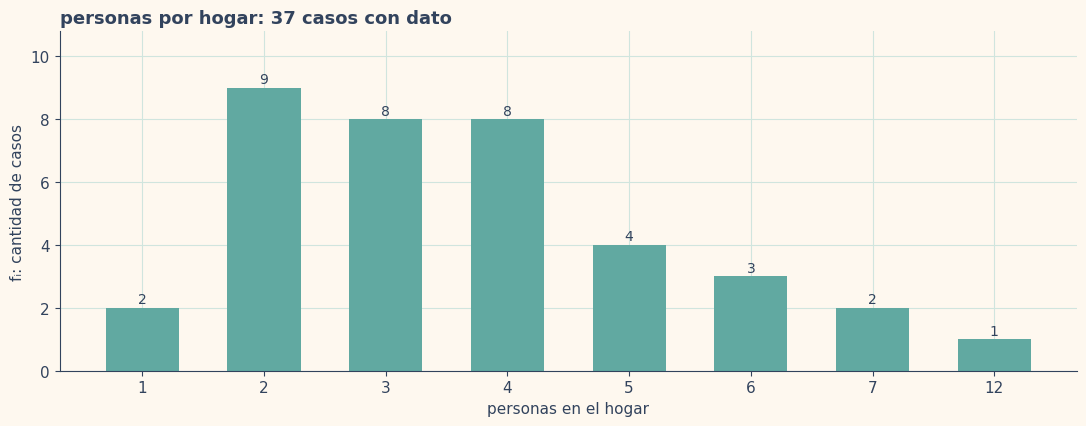

,fᵢ,frᵢ,Fᵢ,Frᵢ
personas en el hogar,,,,
1,2,"0,0541",2,"0,0541"
2,9,"0,2432",11,"0,2973"
3,8,"0,2162",19,"0,5135"
4,8,"0,2162",27,"0,7297"
5,4,"0,1081",31,"0,8378"
6,3,"0,0811",34,"0,9189"
7,2,"0,0541",36,"0,9730"
12,1,"0,0270",37,"1,0000"


Total: 37 casos.  Σ fᵢ = 37   Σ frᵢ = 1,0000


In [3]:
#@title La tabla de frecuencias { run: "auto", display-mode: "form" }

variable = "personas por hogar"  #@param ["personas por hogar", "localidad", "satisfacción", "servicios declarados", "ingreso"]
tratar_el_cero_como_faltante = False  #@param {type:"boolean"}

if variable.startswith("personas"):
    serie, orden, titulo = hogares["personas"], None, "personas en el hogar"
elif variable == "localidad":
    serie, orden, titulo = hogares["localidad"], None, "localidad"
elif variable.startswith("satisfacci"):
    serie, orden, titulo = hogares["satisfaccion"], ORDEN_SATISFACCION, "satisfacción declarada"
elif variable.startswith("servicios"):
    serie, orden, titulo = separar_servicios(hogares["servicios"]), None, "servicio declarado"
else:
    serie, orden, titulo = hogares["ingreso"], None, "ingreso"

if variable == "ingreso" and tratar_el_cero_como_faltante:
    serie = serie[serie > 0]
tabla, total = serie_frecuencia(serie, orden)

fig, ax = plt.subplots(figsize=(11, 4.4))
etiquetas = [str(i) for i in tabla.index]
if variable == "ingreso":
    ax.text(0.5, 0.5, "Los 35 ingresos son todos distintos: la serie de frecuencia\n"
                      "tendría 35 filas con un 1 en cada una. Hay que agrupar, y eso\n"
                      "es la sección 2.3, en el bloque 2 de este notebook.",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)
    ax.set_axis_off()
else:
    ax.bar(etiquetas, tabla["fᵢ"], color=TEAL, width=0.6)
    for i, v in enumerate(tabla["fᵢ"]):
        ax.text(i, v + 0.15, str(int(v)), ha="center", fontsize=10)
    ax.set_ylim(0, tabla["fᵢ"].max() * 1.2)
    ax.set_xlabel(titulo); ax.set_ylabel("fᵢ: cantidad de casos")
    ax.set_title(f"{variable}: {total} casos con dato")
plt.tight_layout(); plt.show()

mostrada = tabla.copy()
mostrada["fᵢ"] = mostrada["fᵢ"].astype(int)
mostrada["Fᵢ"] = mostrada["Fᵢ"].astype(int)
mostrada["frᵢ"] = [num(v) for v in tabla["frᵢ"]]
mostrada["Frᵢ"] = [num(v) for v in tabla["Frᵢ"]]
display(mostrada.rename_axis(titulo))
print(f"Total: {total} casos.  Σ fᵢ = {int(tabla['fᵢ'].sum())}   Σ frᵢ = {num(tabla['frᵢ'].sum())}")
faltan = len(hogares) - total
if variable.startswith("servicios"):
    print(f"Los {total} servicios se reparten entre {len(hogares)} hogares: las categorías no son excluyentes "
          "y por eso la suma pasa el total de hogares.")
elif faltan > 0:
    print(f"{faltan} de los {len(hogares)} hogares no tienen el dato, y hay que declararlo: "
          f"la tabla describe a {total}, no a {len(hogares)}.")
if variable == "ingreso":
    con_cero = hogares["ingreso"].dropna()
    sin_cero = con_cero[con_cero > 0]
    print(f"Con los 35 valores declarados la media es {num(con_cero.mean(), 0)}; "
          f"descartando el cero, {num(sin_cero.mean(), 0)} sobre {len(sin_cero)} valores.")


---
# 2. Los intervalos de clase, y el histograma

*Apunte, secciones 2.3, 2.4 y 7.4.*

Los 35 ingresos son todos distintos, así que hay que **agrupar en intervalos**. Tres decisiones, y
ninguna es automática: cuántos intervalos, de qué amplitud y dónde empieza el primero.

La casilla arma la tabla del apunte: siete clases de 100.000 desde cero. El deslizador deja probar
otras cantidades, y ahí se ve lo de la sección 7.4. Con 3 intervalos el hogar de 620.000 desaparece
dentro de una barra; con 30 queda un peine de barras de altura 1 y no se ve ninguna forma.

Abajo está el precio de agrupar. La media calculada con las **marcas de clase** da 201.429 contra
los 203.471 reales, un 1,0% de diferencia. Si tenés los datos sin agrupar, calculá sobre ellos.


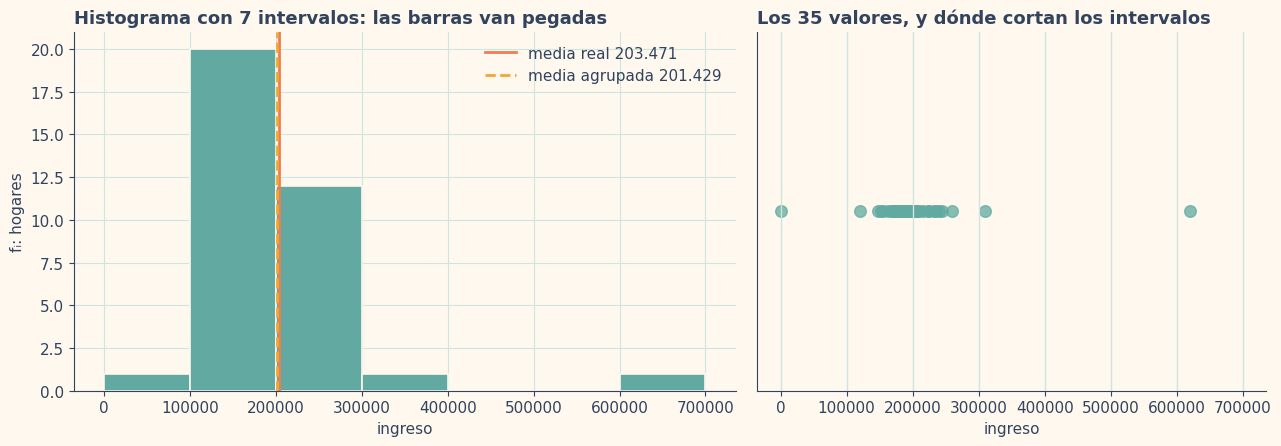

,marca de clase,fᵢ,frᵢ,Fᵢ,Frᵢ
intervalo,,,,,
0 – 100.000,50.000,1,"0,0286",1,"0,0286"
100.000 – 200.000,150.000,20,"0,5714",21,"0,6000"
200.000 – 300.000,250.000,12,"0,3429",33,"0,9429"
300.000 – 400.000,350.000,1,"0,0286",34,"0,9714"
400.000 – 500.000,450.000,0,"0,0000",34,"0,9714"
500.000 – 600.000,550.000,0,"0,0000",34,"0,9714"
600.000 – 700.000,650.000,1,"0,0286",35,"1,0000"


Reglas orientativas para 35 datos: Sturges k = 1 + 3,322 × log₁₀(n) = 6,13     √n = 5,92
Media real, sin agrupar: 203.471
Media calculada con las marcas de clase: 201.429   (diferencia -2.043, un 1,0 %)
Hay 2 clase(s) con fᵢ = 0, y no se borran: el hueco dice que ahí no hay ningún hogar.
Los límites son cerrados a la izquierda y abiertos a la derecha, como numpy y matplotlib. pandas.cut hace lo contrario salvo que se le pida right=False.


In [4]:
#@title Agrupar el ingreso { run: "auto", display-mode: "form" }

usar_la_tabla_del_apunte = True  #@param {type:"boolean"}
cantidad_de_intervalos = 6  #@param {type:"slider", min:2, max:30, step:1}

ingreso = hogares["ingreso"].dropna().to_numpy(dtype=float)
n = len(ingreso)
if usar_la_tabla_del_apunte:
    bordes = np.arange(0, 700001, 100000, dtype=float)
else:
    bordes = np.linspace(ingreso.min(), ingreso.max(), cantidad_de_intervalos + 1)
frecuencias, _ = np.histogram(ingreso, bins=bordes)
marcas = (bordes[:-1] + bordes[1:]) / 2
media_agrupada = (marcas * frecuencias).sum() / frecuencias.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.hist(ingreso, bins=bordes, color=TEAL, edgecolor=CREMA, linewidth=1.2)
ax1.axvline(ingreso.mean(), color=CORAL, linewidth=2, label=f"media real {num(ingreso.mean(), 0)}")
ax1.axvline(media_agrupada, color=MOSTAZA, linewidth=2, linestyle="--",
            label=f"media agrupada {num(media_agrupada, 0)}")
ax1.set_xlabel("ingreso"); ax1.set_ylabel("fᵢ: hogares")
ax1.legend(loc="upper right")
ax1.set_title(f"Histograma con {len(bordes) - 1} intervalos: las barras van pegadas")
recta_de_puntos(ax2, ingreso, color=TEAL)
for borde in bordes:
    ax2.axvline(borde, color=TEAL_PALIDO, linewidth=1)
ax2.set_yticks([]); ax2.set_ylim(-1, 1); ax2.grid(False)
ax2.set_xlabel("ingreso"); ax2.set_title("Los 35 valores, y dónde cortan los intervalos")
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({
    "intervalo": [f"{num(a, 0)} – {num(b, 0)}" for a, b in zip(bordes[:-1], bordes[1:])],
    "marca de clase": [num(v, 0) for v in marcas],
    "fᵢ": frecuencias,
    "frᵢ": [num(v / n) for v in frecuencias],
    "Fᵢ": np.cumsum(frecuencias),
    "Frᵢ": [num(v / n) for v in np.cumsum(frecuencias)],
}).set_index("intervalo")
display(tabla)
print(f"Reglas orientativas para {n} datos: Sturges k = 1 + 3,322 × log₁₀(n) = "
      f"{num(1 + 3.322 * np.log10(n), 2)}     √n = {num(np.sqrt(n), 2)}")
print(f"Media real, sin agrupar: {num(ingreso.mean(), 0)}")
print(f"Media calculada con las marcas de clase: {num(media_agrupada, 0)}   "
      f"(diferencia {num(media_agrupada - ingreso.mean(), 0)}, un {num(100 * abs(media_agrupada - ingreso.mean()) / ingreso.mean(), 1)} %)")
vacias = int((frecuencias == 0).sum())
if vacias:
    print(f"Hay {vacias} clase(s) con fᵢ = 0, y no se borran: el hueco dice que ahí no hay ningún hogar.")
print("Los límites son cerrados a la izquierda y abiertos a la derecha, como numpy y matplotlib. "
      "pandas.cut hace lo contrario salvo que se le pida right=False.")


---
# 3. Las tres medidas de posición

*Apunte, secciones 3.1 a 3.4.*

La **media** es el punto de equilibrio y usa todos los datos, así que un valor lejano la corre. La
**mediana** parte la serie ordenada al medio, y depende del orden y no de la magnitud: es
**resistente**. El **modo** es el valor que más se repite, y en el ingreso no existe, porque los 35
valores son distintos.

El deslizador mueve el ingreso del hogar 39, que en el relevamiento declaró 620.000. Llevalo a
6.200.000, que es la comprobación de la sección 3.3: la media pasa de 203.471 a 362.900 y **la
mediana sigue siendo 193.000**.

La regla corta de la sección 3.4: si la distribución es aproximadamente simétrica, informá la media;
si está estirada o tiene valores extremos, informá la mediana, y decí las dos.


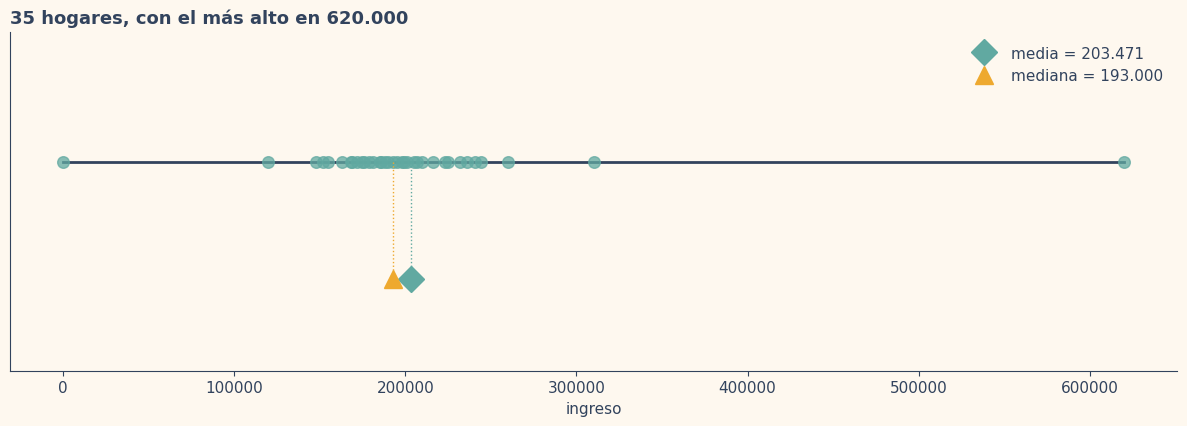

,con el valor original (620.000),con el valor movido
media,203.471,203.471
mediana,193.000,193.000
desvío standard,86.103,86.103
Q₃ − Q₁ (RIC),46.000,46.000


22 de los 35 hogares están por debajo de la media. La mediana deja 17 de cada lado, siempre.
El modo del ingreso no existe: los 35 valores son distintos, así que la serie es amodal.
En las personas por hogar sí hay modo: 2, con 9 hogares. Media 3,7838 y mediana 3.
El modo es la única medida de posición que sirve para una variable nominal: la localidad más frecuente es Ramallo, con 15 hogares.


In [5]:
#@title Mover el valor más alto { run: "auto", display-mode: "form" }

ingreso_del_hogar_39 = 620000  #@param {type:"slider", min:250000, max:6200000, step:10000}

ingreso = hogares["ingreso"].dropna().to_numpy(dtype=float)
modificado = np.sort(ingreso).copy()
modificado[-1] = max(ingreso_del_hogar_39, modificado[-2])
media, mediana = modificado.mean(), float(np.median(modificado))
por_debajo = int((modificado < media).sum())

fig, ax = plt.subplots(figsize=(12, 4.4))
recta_de_puntos(ax, modificado, color=TEAL)
ax.plot([modificado.min(), modificado.max()], [0, 0], color=TINTA, linewidth=2, zorder=0)
for valor, marca, color, etiqueta in [
        (media, "D", TEAL, f"media = {num(media, 0)}"),
        (mediana, "^", MOSTAZA, f"mediana = {num(mediana, 0)}")]:
    ax.plot([valor, valor], [0, -0.45], color=color, linewidth=1, linestyle=":", clip_on=False)
    ax.plot(valor, -0.45, marca, color=color, markersize=13, clip_on=False, label=etiqueta)
ax.set_ylim(-0.8, 0.5); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel("ingreso"); ax.legend(loc="upper right")
ax.set_title(f"35 hogares, con el más alto en {num(modificado[-1], 0)}")
plt.tight_layout(); plt.show()

original = np.sort(ingreso)
resumen = pd.DataFrame({
    "con el valor original (620.000)": {"media": num(original.mean(), 0),
                                        "mediana": num(float(np.median(original)), 0),
                                        "desvío standard": num(original.std(ddof=0), 0),
                                        "Q₃ − Q₁ (RIC)": num(np.subtract(*np.percentile(original, [75, 25])), 0)},
    "con el valor movido": {"media": num(media, 0), "mediana": num(mediana, 0),
                            "desvío standard": num(modificado.std(ddof=0), 0),
                            "Q₃ − Q₁ (RIC)": num(np.subtract(*np.percentile(modificado, [75, 25])), 0)},
})
display(resumen)
print(f"{por_debajo} de los 35 hogares están por debajo de la media. La mediana deja 17 de cada lado, siempre.")
print("El modo del ingreso no existe: los 35 valores son distintos, así que la serie es amodal.")
personas = hogares["personas"]
print(f"En las personas por hogar sí hay modo: {int(personas.mode().iloc[0])}, con "
      f"{int(personas.value_counts().max())} hogares. Media {num(personas.mean(), 4)} y mediana "
      f"{num(float(personas.median()), 0)}.")
print("El modo es la única medida de posición que sirve para una variable nominal: la localidad más "
      f"frecuente es {hogares['localidad'].mode().iloc[0]}, con {int(hogares['localidad'].value_counts().max())} hogares.")


---
# 4. Los cuartiles, y los dos métodos

*Apunte, sección 3.5.*

Los cuartiles parten la serie ordenada en cuatro. `Q₁` deja el 25% por debajo, `Q₂` es la mediana y
`Q₃` deja el 75%.

Y acá hay algo que conviene saber antes de informar un número. La fórmula clásica de la posición,
`k(n + 1)/4`, da `172.000` y `223.000` para el ingreso; `pandas` y `numpy` dan `173.500` y
`219.500`, porque reparten la posición sobre `n − 1`. **Ninguno de los dos está mal.** La mediana
coincide siempre, los otros dos no tienen por qué, y lo que no se puede hacer es informar un cuartil
sin decir con qué método se calculó.

El apunte usa los de `pandas` y `numpy`, que son los que publicó el T8001. El deslizador generaliza:
los **percentiles** parten en cien, y el percentil 90 deja al 90% de los hogares por debajo.


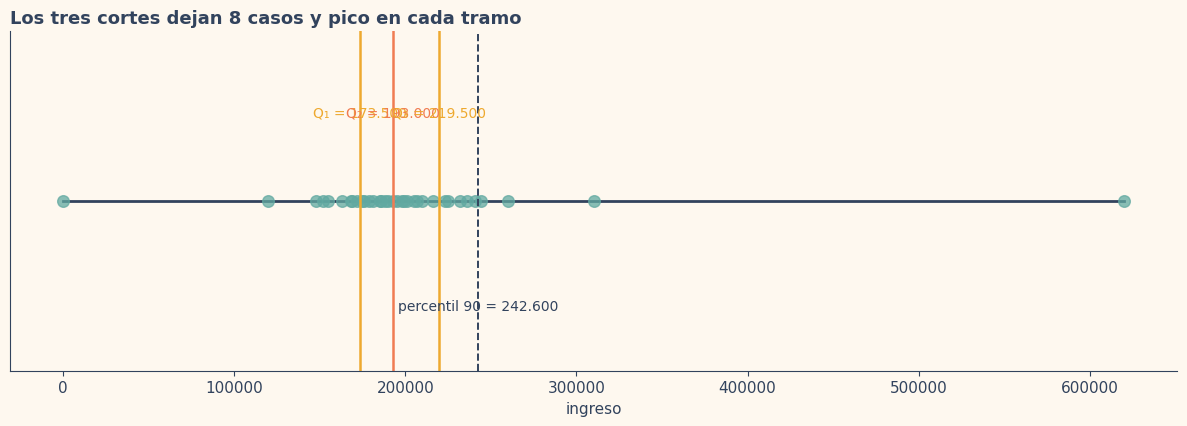

,fórmula k(n+1)/4,pandas y numpy
Q₁,172.000,173.500
Q₂ (mediana),193.000,193.000
Q₃,223.000,219.500
RIC,51.000,46.000


Posiciones de la fórmula, con n = 35: Q1 → 9,00   Q2 → 18,00   Q3 → 27,00
Se lee: la cuarta parte de los casos está por debajo de 173.500, y la cuarta parte por encima de 219.500.
Y el percentil 90 deja al 90 % de los casos por debajo de 242.600.
La mediana coincide con los dos métodos; Q₁ y Q₃ no tienen por qué.


In [6]:
#@title Cuartiles y percentiles { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]
percentil = 90  #@param {type:"slider", min:1, max:99, step:1}

x = (hogares["ingreso"].dropna() if variable == "ingreso" else hogares["personas"]).to_numpy(dtype=float)
orden = np.sort(x)
n = len(orden)
q_pandas = np.percentile(orden, [25, 50, 75])
q_formula = [cuartil_formula(orden, k) for k in (1, 2, 3)]
valor_percentil = np.percentile(orden, percentil)

fig, ax = plt.subplots(figsize=(12, 4.4))
recta_de_puntos(ax, orden, color=TEAL)
ax.plot([orden.min(), orden.max()], [0, 0], color=TINTA, linewidth=2, zorder=0)
for valor, color, etiqueta in zip(q_pandas, [MOSTAZA, CORAL, MOSTAZA], ["Q₁", "Q₂", "Q₃"]):
    ax.axvline(valor, color=color, linewidth=1.8)
    ax.text(valor, 0.35, f"{etiqueta} = {num(valor, 0)}", ha="center", fontsize=10, color=color)
ax.axvline(valor_percentil, color=TINTA, linewidth=1.4, linestyle="--")
ax.text(valor_percentil, -0.45, f"percentil {percentil} = {num(valor_percentil, 0)}", ha="center", fontsize=10)
ax.set_ylim(-0.7, 0.7); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel(variable); ax.set_title(f"Los tres cortes dejan {n // 4} casos y pico en cada tramo")
plt.tight_layout(); plt.show()

comparacion = pd.DataFrame({
    "fórmula k(n+1)/4": [num(v, 0) for v in q_formula] + [num(q_formula[2] - q_formula[0], 0)],
    "pandas y numpy": [num(v, 0) for v in q_pandas] + [num(q_pandas[2] - q_pandas[0], 0)],
}, index=["Q₁", "Q₂ (mediana)", "Q₃", "RIC"])
display(comparacion)
print(f"Posiciones de la fórmula, con n = {n}: " +
      "   ".join(f"Q{k} → {num(k * (n + 1) / 4, 2)}" for k in (1, 2, 3)))
print(f"Se lee: la cuarta parte de los casos está por debajo de {num(q_pandas[0], 0)}, "
      f"y la cuarta parte por encima de {num(q_pandas[2], 0)}.")
print(f"Y el percentil {percentil} deja al {percentil} % de los casos por debajo de {num(valor_percentil, 0)}.")
print("La mediana coincide con los dos métodos; Q₁ y Q₃ no tienen por qué.")


---
# 5. La variabilidad, y el divisor `n` o `n − 1`

*Apunte, secciones 4.1 a 4.5.*

El **rango** es la diferencia entre el máximo y el mínimo, y depende de dos datos solos: sin el
hogar de 620.000, el del ingreso se parte al medio. El **desvío standard** usa todos los datos. El
**`RIC`** usa solo la mitad central y por eso es resistente.

La casilla cambia el divisor, y es la única diferencia de fondo entre esta unidad y la unidad 2.
Dividir por `n` describe la dispersión **de los datos que están**; dividir por `n − 1` corrige la
subestimación que aparece cuando esos datos son una **muestra** de algo más grande. Con estos
tamaños la diferencia es del orden del 1,4%.

Y ojo con las herramientas, porque no hacen lo mismo: **`pandas` divide por `n − 1` y `numpy` divide
por `n`**, sobre los mismos datos.


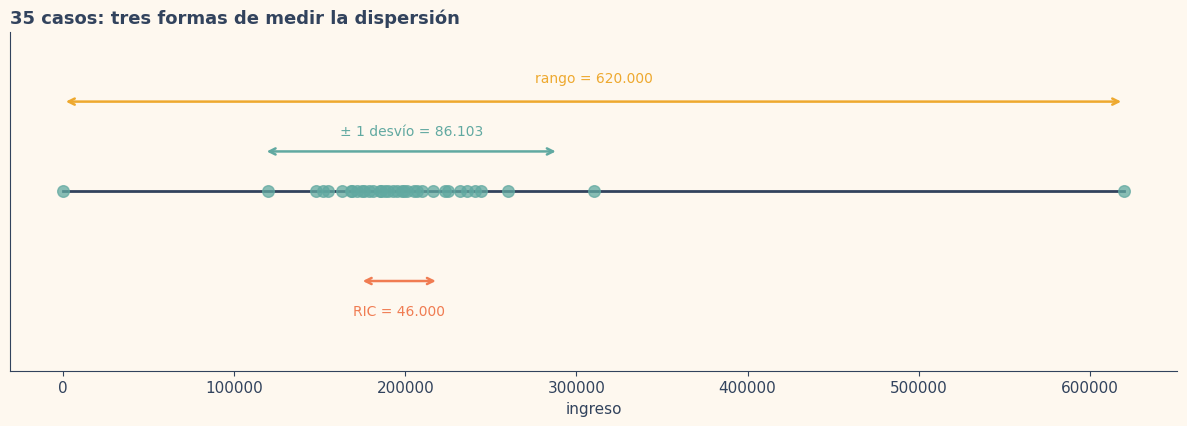

,valor
rango,620.000
varianza,7.413.642.041
desvío standard,86.103
RIC,46.000
CV (%),"42,32"


Divisor elegido: n (la distribución completa)
  con n     → 86.102,5089      (es lo que devuelve np.std)
  con n − 1 → 87.359,5463      (es lo que devuelve Series.std de pandas)
  diferencia: 1,46 %

Desvío 86.103 contra RIC 46.000: el desvío es el más grande, porque el valor extremo lo infla y el RIC no lo usa.
El CV es el que permite comparar: personas por hogar 54,66 % contra ingreso 42,32 %. Las personas por hogar varían relativamente más.


In [7]:
#@title Rango, desvío, RIC y CV { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]
divisor = "n (la distribución completa)"  #@param ["n (la distribución completa)", "n − 1 (una muestra)"]
sacar_el_valor_mas_alto = False  #@param {type:"boolean"}

serie = hogares["ingreso"].dropna() if variable == "ingreso" else hogares["personas"]
x = np.sort(serie.to_numpy(dtype=float))
if sacar_el_valor_mas_alto:
    x = x[:-1]
ddof = 0 if divisor.startswith("n (") else 1
bajo, alto, q1, q3, ric = limites_ric(x)
rango = x.max() - x.min()
desvio = x.std(ddof=ddof)

fig, ax = plt.subplots(figsize=(12, 4.4))
recta_de_puntos(ax, x, color=TEAL)
ax.plot([x.min(), x.max()], [0, 0], color=TINTA, linewidth=2, zorder=0)
ax.annotate("", xy=(x.min(), 0.45), xytext=(x.max(), 0.45),
            arrowprops=dict(arrowstyle="<->", color=MOSTAZA, linewidth=1.8))
ax.text((x.min() + x.max()) / 2, 0.55, f"rango = {num(rango, 0)}", ha="center", color=MOSTAZA, fontsize=10)
ax.annotate("", xy=(q1, -0.45), xytext=(q3, -0.45),
            arrowprops=dict(arrowstyle="<->", color=CORAL, linewidth=1.8))
ax.text((q1 + q3) / 2, -0.62, f"RIC = {num(ric, 0)}", ha="center", color=CORAL, fontsize=10)
ax.annotate("", xy=(x.mean() - desvio, 0.2), xytext=(x.mean() + desvio, 0.2),
            arrowprops=dict(arrowstyle="<->", color=TEAL, linewidth=1.8))
ax.text(x.mean(), 0.28, f"± 1 desvío = {num(desvio, 0)}", ha="center", color=TEAL, fontsize=10)
ax.set_ylim(-0.9, 0.8); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel(variable); ax.set_title(f"{len(x)} casos: tres formas de medir la dispersión")
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({
    "valor": {
        "rango": num(rango, 0),
        "varianza": num(x.var(ddof=ddof), 4 if variable.startswith("personas") else 0),
        "desvío standard": num(desvio, 4 if variable.startswith("personas") else 0),
        "RIC": num(ric, 0),
        "CV (%)": num(100 * x.std(ddof=0) / x.mean(), 2) if x.mean() else "—",
    }})
display(tabla)
print(f"Divisor elegido: {divisor}")
print(f"  con n     → {num(x.std(ddof=0), 4)}      (es lo que devuelve np.std)")
print(f"  con n − 1 → {num(x.std(ddof=1), 4)}      (es lo que devuelve Series.std de pandas)")
print(f"  diferencia: {num(100 * (x.std(ddof=1) - x.std(ddof=0)) / x.std(ddof=0), 2)} %")
print()
print(f"Desvío {num(x.std(ddof=0), 0)} contra RIC {num(ric, 0)}: "
      + ("el desvío es el más grande, porque el valor extremo lo infla y el RIC no lo usa."
         if x.std(ddof=0) > ric else "acá los dos quedan parecidos, porque no hay ningún valor muy alejado."))
ingreso = hogares["ingreso"].dropna().to_numpy(dtype=float)
personas = hogares["personas"].to_numpy(dtype=float)
print(f"El CV es el que permite comparar: personas por hogar {num(100 * personas.std(ddof=0) / personas.mean(), 2)} % "
      f"contra ingreso {num(100 * ingreso.std(ddof=0) / ingreso.mean(), 2)} %. "
      "Las personas por hogar varían relativamente más.")


---
# 6. La asimetría, la kurtosis y las convenciones

*Apunte, secciones 5.1 a 5.3.*

Las dos medidas de forma de la unidad 2, ahora sobre datos. El ingreso es el caso más marcado del
relevamiento: `α₃ = 2,8714` y `α₄ = 16,6556` contra el 3 de la normal.

Los **coeficientes de Pearson** son dos atajos que aparecen en la bibliografía, y salen de la
observación de la unidad 2: con la cola hacia la derecha, la media queda por encima de la mediana y
del modo. `Ap₁` no se puede calcular sobre el ingreso, porque la serie es amodal, y esa es la razón
para preferir `Ap₂`.

Los tres coeficientes coinciden en el **signo** y no en la **magnitud**, así que no son
intercambiables. Y la tabla de abajo es la de la sección 5.3: cinco llamadas, cinco números, los
mismos datos. Los del apunte son los de `scipy` sin corregir.


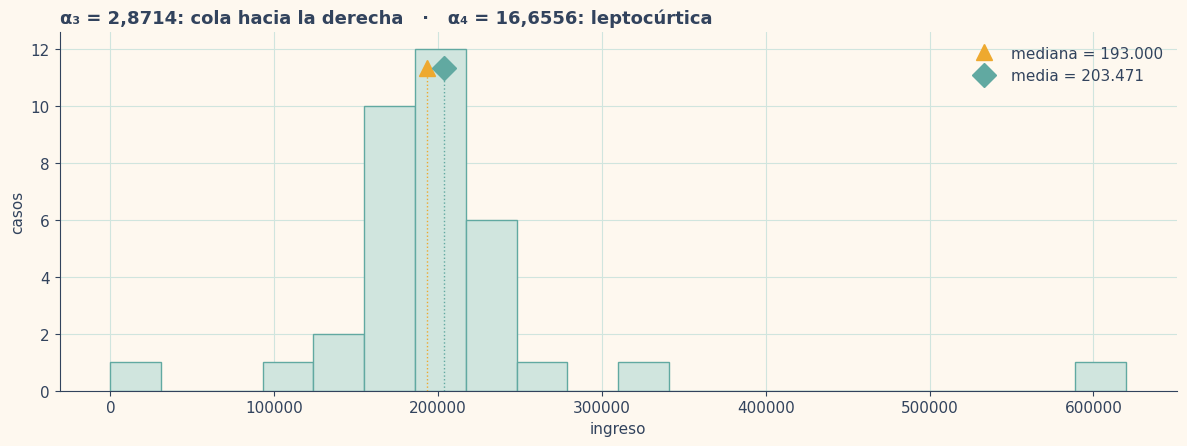

,valor
α₃,"2,8714"
Ap₁ = (x̄ − modo) / s,—
Ap₂ = 3(x̄ − mediana) / s,"0,3648"
α₄,"16,6556"


El Ap₁ no existe: la serie es amodal, y por eso se prefiere el Ap₂, que se puede calcular siempre.
Los tres coeficientes de asimetría coinciden en el signo y no en la magnitud: no son intercambiables.

Las cinco llamadas de la sección 5.3, sobre los mismos datos:


,resultado,qué devuelve
scipy.stats.skew(x),"2,8714","α₃, distribución completa"
pandas: x.skew(),"3,0016","α₃, corregido por muestra"
"scipy.stats.kurtosis(x, fisher=False)","16,6556","α₄, distribución completa"
scipy.stats.kurtosis(x),"13,6556","exceso, distribución completa"
pandas: x.kurt(),"16,0213","exceso, corregido por muestra"


In [8]:
#@title Las medidas de forma, y qué informa cada herramienta { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]

serie = hogares["ingreso"].dropna() if variable == "ingreso" else hogares["personas"]
x = serie.to_numpy(dtype=float)
media, mediana = x.mean(), float(np.median(x))
s = x.std(ddof=0)
repite = pd.Series(x).value_counts().max() > 1
modo = float(pd.Series(x).mode().iloc[0]) if repite else np.nan
a3, a4 = stats.skew(x), stats.kurtosis(x, fisher=False)
ap1 = (media - modo) / s if repite else np.nan
ap2 = 3 * (media - mediana) / s

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.hist(x, bins=min(20, len(np.unique(x))), color=TEAL_PALIDO, edgecolor=TEAL)
altura = ax.get_ylim()[1]
for valor, marca, color, etiqueta in [
        (modo, "o", CORAL, "modo"), (mediana, "^", MOSTAZA, "mediana"), (media, "D", TEAL, "media")]:
    if np.isnan(valor):
        continue
    ax.plot([valor, valor], [0, altura * 0.9], color=color, linewidth=1, linestyle=":")
    ax.plot(valor, altura * 0.9, marca, color=color, markersize=12, label=f"{etiqueta} = {num(valor, 0)}")
ax.legend(loc="upper right"); ax.set_xlabel(variable); ax.set_ylabel("casos")
ax.set_title(f"α₃ = {num(a3, 4)}: "
             + ("cola hacia la derecha" if a3 > 0.05 else "cola hacia la izquierda" if a3 < -0.05 else "simétrica")
             + f"   ·   α₄ = {num(a4, 4)}: " + ("leptocúrtica" if a4 > 3 else "platicúrtica"))
plt.tight_layout(); plt.show()

display(pd.DataFrame({"valor": {"α₃": num(a3, 4), "Ap₁ = (x̄ − modo) / s": num(ap1, 4),
                                "Ap₂ = 3(x̄ − mediana) / s": num(ap2, 4), "α₄": num(a4, 4)}}))
if not repite:
    print("El Ap₁ no existe: la serie es amodal, y por eso se prefiere el Ap₂, que se puede calcular siempre.")
print("Los tres coeficientes de asimetría coinciden en el signo y no en la magnitud: no son intercambiables.")
print()
print("Las cinco llamadas de la sección 5.3, sobre los mismos datos:")
display(pd.DataFrame({
    "resultado": {
        "scipy.stats.skew(x)": num(stats.skew(x), 4),
        "pandas: x.skew()": num(serie.skew(), 4),
        "scipy.stats.kurtosis(x, fisher=False)": num(stats.kurtosis(x, fisher=False), 4),
        "scipy.stats.kurtosis(x)": num(stats.kurtosis(x), 4),
        "pandas: x.kurt()": num(serie.kurt(), 4)},
    "qué devuelve": {
        "scipy.stats.skew(x)": "α₃, distribución completa",
        "pandas: x.skew()": "α₃, corregido por muestra",
        "scipy.stats.kurtosis(x, fisher=False)": "α₄, distribución completa",
        "scipy.stats.kurtosis(x)": "exceso, distribución completa",
        "pandas: x.kurt()": "exceso, corregido por muestra"}}))


---
# 7. Los dos criterios de valor extremo

*Apunte, sección 6.*

El **z-score** mide cuántos desvíos separan al valor de la media, y el umbral habitual es 3. La
**regla del `1,5 × RIC`** marca lo que cae fuera de `[Q₁ − 1,5 RIC, Q₃ + 1,5 RIC]`.

Con el ingreso, los dos criterios discrepan en dos de los tres candidatos. La razón está a la vista
en el gráfico: el z-score usa la media y el desvío, y **los dos ya están corridos por el propio
hogar de 620.000**, que infló el desvío hasta 86.103. El `RIC` no lo sufre, porque no usa ni la
media ni el desvío.

Bajá el umbral del z-score a 2, que es el que usó el T8001, y vas a ver que el `0` del hogar 38
también queda marcado. Un valor atípico es una señal para mirar, no una instrucción para borrar.


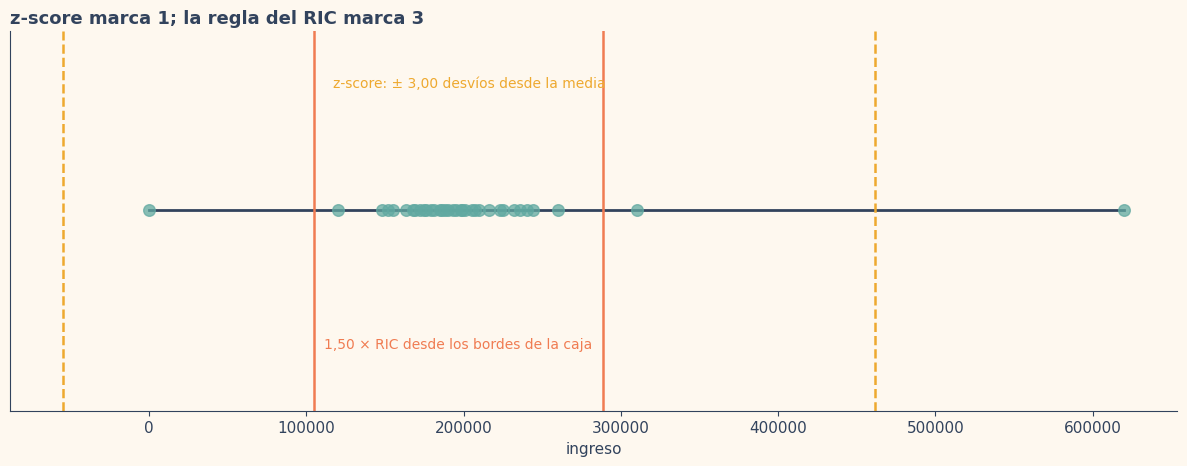

,valor,z-score,"|z| > 3,00","1,50 × RIC"
hogar,,,,
7,310.000,"1,24",no lo marca,lo marca
38,0,"-2,36",no lo marca,lo marca
39,620.000,"4,84",lo marca,lo marca


Media 203.471   desvío 86.103   Q₁ 173.500   Q₃ 219.500   RIC 46.000
Límites del RIC: 104.500 y 288.500
Techo del z-score con divisor n y 35 datos: √(n − 1) = 5,83. Con menos de once casos ningún valor puede superar 3, por extremo que sea.


In [9]:
#@title z-score contra 1,5 × RIC { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]
umbral_del_z_score = 3.0  #@param {type:"slider", min:1, max:4, step:0.25}
factor_del_ric = 1.5  #@param {type:"slider", min:1, max:3, step:0.25}

serie = hogares["ingreso"].dropna() if variable == "ingreso" else hogares["personas"]
x = serie.to_numpy(dtype=float)
identificadores = hogares.loc[serie.index, "id_hogar"].to_numpy()
media, s = x.mean(), x.std(ddof=0)
z = (x - media) / s
bajo, alto, q1, q3, ric = limites_ric(x, factor_del_ric)
marca_z = np.abs(z) > umbral_del_z_score
marca_ric = (x < bajo) | (x > alto)

fig, ax = plt.subplots(figsize=(12, 4.8))
recta_de_puntos(ax, x, color=TEAL)
ax.plot([min(x.min(), bajo), max(x.max(), alto)], [0, 0], color=TINTA, linewidth=2, zorder=0)
for limite in (media - umbral_del_z_score * s, media + umbral_del_z_score * s):
    ax.axvline(limite, color=MOSTAZA, linewidth=1.8, linestyle="--")
ax.text(media, 0.55, f"z-score: ± {num(umbral_del_z_score, 2)} desvíos desde la media",
        ha="center", color=MOSTAZA, fontsize=10)
for limite in (bajo, alto):
    ax.axvline(limite, color=CORAL, linewidth=1.8)
ax.text((q1 + q3) / 2, -0.62, f"{num(factor_del_ric, 2)} × RIC desde los bordes de la caja",
        ha="center", color=CORAL, fontsize=10)
ax.set_ylim(-0.9, 0.8); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel(variable)
ax.set_title(f"z-score marca {int(marca_z.sum())}; la regla del RIC marca {int(marca_ric.sum())}")
plt.tight_layout(); plt.show()

candidatos = marca_z | marca_ric
if candidatos.any():
    display(pd.DataFrame({
        "hogar": identificadores[candidatos],
        "valor": [num(v, 0) for v in x[candidatos]],
        "z-score": [num(v, 2) for v in z[candidatos]],
        f"|z| > {num(umbral_del_z_score, 2)}": ["lo marca" if v else "no lo marca" for v in marca_z[candidatos]],
        f"{num(factor_del_ric, 2)} × RIC": ["lo marca" if v else "no lo marca" for v in marca_ric[candidatos]],
    }).set_index("hogar"))
else:
    print("Con estos umbrales ninguno de los dos criterios marca un valor.")
print(f"Media {num(media, 0)}   desvío {num(s, 0)}   Q₁ {num(q1, 0)}   Q₃ {num(q3, 0)}   RIC {num(ric, 0)}")
print(f"Límites del RIC: {num(bajo, 0)} y {num(alto, 0)}")
print(f"Techo del z-score con divisor n y {len(x)} datos: √(n − 1) = {num(np.sqrt(len(x) - 1), 2)}. "
      "Con menos de once casos ningún valor puede superar 3, por extremo que sea.")


---
# 8. El gráfico de barras y el sectorial

*Apunte, secciones 7.1 a 7.3.*

El gráfico se elige por el tipo de variable. Para una cualitativa va el **gráfico de barras**, con
las barras separadas, porque entre Ramallo y Córdoba no hay nada.

Dos reglas, y las dos tienen su casilla. **El eje empieza en cero**: truncarlo multiplica
visualmente las diferencias, y con el eje empezando en 10 Ramallo parece cinco veces Córdoba en
lugar de 1,4 veces. Y **el orden depende de la escala**: en una nominal conviene ordenar por
frecuencia, y en una ordinal hay que respetar el orden propio de la variable. La satisfacción es
ordinal: ordenarla por frecuencia escondería que la mayoría está en el medio.

El sectorial sirve para una sola cosa, mostrar qué parte del total ocupa cada categoría, y el ojo
compara longitudes mucho mejor que ángulos. Con `servicios` no se puede usar: los 88 servicios de 37
hogares no suman un total que se pueda repartir.


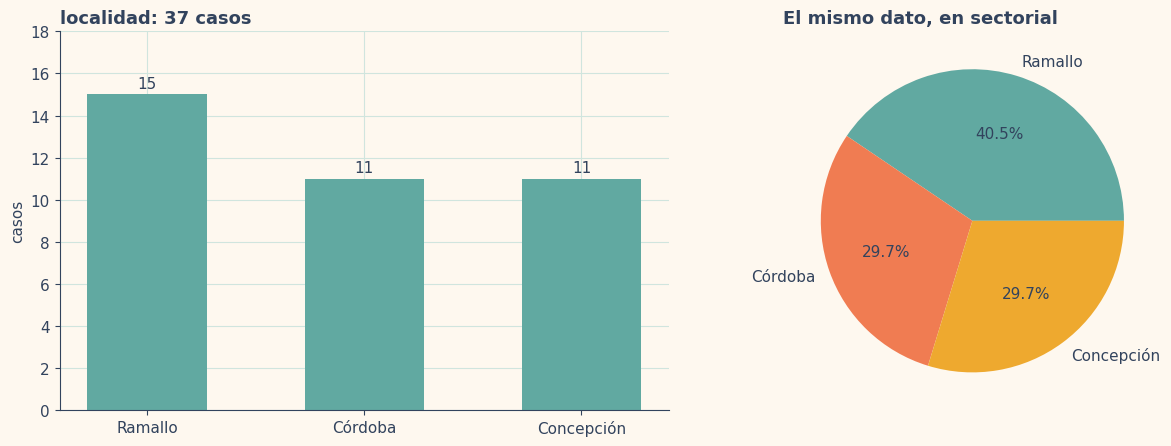

,casos,proporción
localidad,,
Ramallo,15,"0,4054"
Córdoba,11,"0,2973"
Concepción,11,"0,2973"


In [10]:
#@title Barras, orden y eje { run: "auto", display-mode: "form" }

variable = "localidad"  #@param ["localidad", "satisfacción", "servicios declarados"]
ordenar_por_frecuencia = True  #@param {type:"boolean"}
truncar_el_eje = False  #@param {type:"boolean"}

if variable == "localidad":
    serie, ordinal = hogares["localidad"], False
elif variable.startswith("satisfacci"):
    serie, ordinal = hogares["satisfaccion"], True
else:
    serie, ordinal = separar_servicios(hogares["servicios"]), False

conteo = serie.dropna().value_counts()
if ordinal and not ordenar_por_frecuencia:
    conteo = conteo.reindex(ORDEN_SATISFACCION).dropna().astype(int)
elif not ordenar_por_frecuencia:
    conteo = conteo.sort_index()
total = int(conteo.sum())
suma_categorias = int(serie.dropna().nunique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.bar(conteo.index.astype(str), conteo.to_numpy(), color=TEAL, width=0.55)
for i, v in enumerate(conteo.to_numpy()):
    ax1.text(i, v + 0.3, str(int(v)), ha="center")
if truncar_el_eje:
    ax1.set_ylim(max(0, conteo.min() - 1), conteo.max() * 1.05)
    ax1.set_title("Eje truncado: las diferencias se ven más grandes de lo que son")
else:
    ax1.set_ylim(0, conteo.max() * 1.2)
    ax1.set_title(f"{variable}: {total} casos")
ax1.set_ylabel("casos")

if variable.startswith("servicios"):
    ax2.text(0.5, 0.5, "Un sectorial no corresponde acá.\nCada hogar declara varios servicios, así que\n"
                       "las categorías no son excluyentes y no hay\nun total que repartir.",
             ha="center", va="center", transform=ax2.transAxes, fontsize=12)
    ax2.set_axis_off()
else:
    ax2.pie(conteo.to_numpy(), labels=[str(i) for i in conteo.index], autopct="%1.1f%%",
            colors=[TEAL, CORAL, MOSTAZA, TEAL_PALIDO, TINTA][:len(conteo)],
            textprops={"color": TINTA})
    ax2.set_title("El mismo dato, en sectorial")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"casos": conteo.astype(int),
                      "proporción": [num(v / total) for v in conteo.to_numpy()]}).rename_axis(variable))
if variable.startswith("servicios"):
    print(f"{total} servicios declarados sobre {len(hogares)} hogares: la suma pasa el total porque las "
          "categorías no son excluyentes. Va en barras y no en sectorial.")
else:
    faltan = len(hogares) - total
    if faltan:
        print(f"{faltan} hogares no declararon el dato, y el gráfico tiene que decirlo: describe a {total}.")
if ordinal and ordenar_por_frecuencia:
    print("La satisfacción es ordinal. Ordenada por frecuencia se rompe la escala, y se pierde que la "
          "mayoría está en el medio. Destildá la casilla del orden.")
if truncar_el_eje:
    mayor, menor = conteo.max(), conteo.min()
    print(f"Con el eje en cero, {mayor} contra {menor} es {num(mayor / menor, 1)} veces. "
          "Con el eje truncado, la barra más alta parece varias veces la más baja. Los datos son los mismos.")


---
# 9. El boxplot

*Apunte, sección 7.6.*

El boxplot dibuja de una vez casi todo lo de las secciones 3 a 6: la caja va de `Q₁` a `Q₃`, la
línea de adentro es la mediana, los bigotes llegan hasta el dato más alejado que todavía cae dentro
de los límites del `1,5 × RIC`, y los puntos sueltos son los atípicos.

Detenete en los bigotes, que es donde más se confunde el dibujo con la regla. Para el ingreso el
límite inferior es 104.500 y el bigote termina en 120.000, que es el dato más bajo por encima de ese
límite. **Los bigotes terminan en un dato real.**

Donde más rinde es comparando grupos, y eso es la casilla. Y lo que el boxplot no muestra es la
forma: dos distribuciones muy distintas pueden dar el mismo dibujo, así que se informa junto con el
histograma.


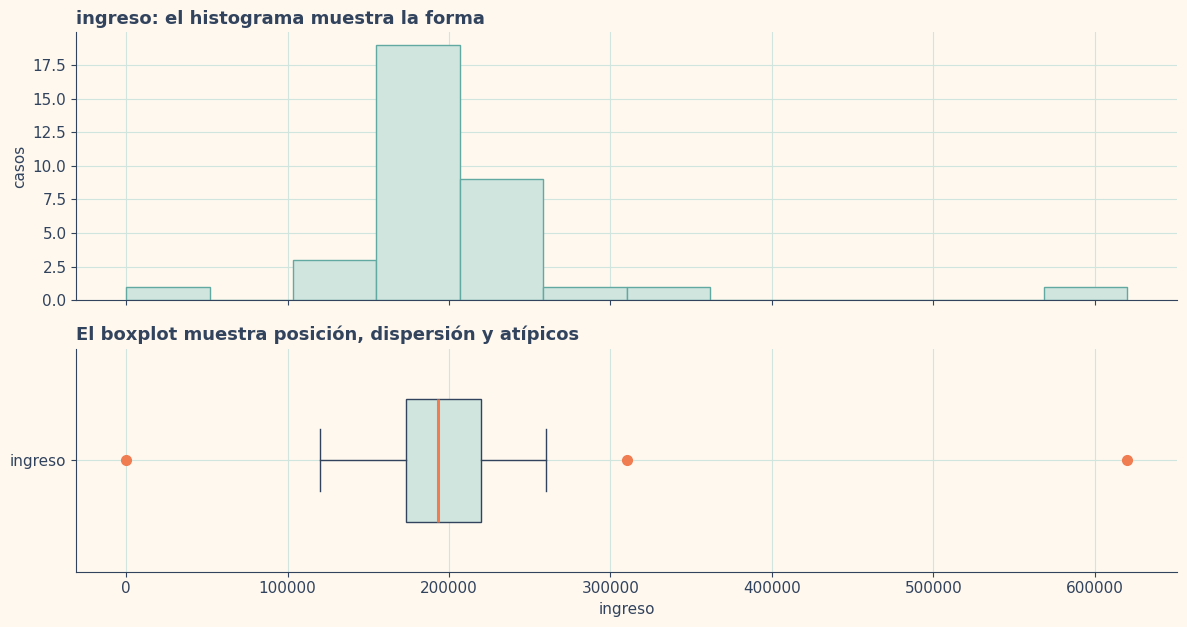

,valor
mínimo,0
bigote inferior,120.000
Q₁,173.500
mediana,193.000
Q₃,219.500
bigote superior,260.000
máximo,620.000
límite inferior de la regla,104.500
límite superior de la regla,288.500


Atípicos: 0, 310.000, 620.000
El límite inferior de la regla es 104.500 y el bigote termina en 120.000: el bigote se apoya en un dato real, no en el límite calculado.
El boxplot no muestra la forma: para eso hace falta el histograma, y por eso los dos se informan juntos.


In [11]:
#@title Caja, bigotes y atípicos { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]
comparar_por_localidad = False  #@param {type:"boolean"}

columna = "ingreso" if variable == "ingreso" else "personas"
datos = hogares[["localidad", columna]].dropna()
x = datos[columna].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [1.2, 1]})
ax1.hist(x, bins=12, color=TEAL_PALIDO, edgecolor=TEAL)
ax1.set_ylabel("casos"); ax1.set_title(f"{variable}: el histograma muestra la forma")
if comparar_por_localidad:
    grupos = [g[columna].to_numpy(dtype=float) for _, g in datos.groupby("localidad")]
    caja(ax2, grupos, list(datos.groupby("localidad").groups))
    ax2.set_title("Un boxplot por localidad: centro y dispersión de cada grupo")
else:
    caja(ax2, [x], [variable])
    ax2.set_title("El boxplot muestra posición, dispersión y atípicos")
ax2.set_xlabel(variable)
plt.tight_layout(); plt.show()

bajo, alto, q1, q3, ric = limites_ric(x)
adentro = x[(x >= bajo) & (x <= alto)]
atipicos = np.sort(x[(x < bajo) | (x > alto)])
resumen = pd.DataFrame({"valor": {
    "mínimo": num(x.min(), 0), "bigote inferior": num(adentro.min(), 0),
    "Q₁": num(q1, 0), "mediana": num(float(np.median(x)), 0), "Q₃": num(q3, 0),
    "bigote superior": num(adentro.max(), 0), "máximo": num(x.max(), 0),
    "límite inferior de la regla": num(bajo, 0), "límite superior de la regla": num(alto, 0)}})
display(resumen)
print("Atípicos: " + (", ".join(num(v, 0) for v in atipicos) if len(atipicos) else "ninguno"))
print(f"El límite inferior de la regla es {num(bajo, 0)} y el bigote termina en {num(adentro.min(), 0)}: "
      "el bigote se apoya en un dato real, no en el límite calculado.")
if comparar_por_localidad:
    for nombre, grupo in datos.groupby("localidad"):
        v = grupo[columna].to_numpy(dtype=float)
        print(f"  {nombre}: {len(v)} casos, mediana {num(float(np.median(v)), 0)}, "
              f"RIC {num(np.subtract(*np.percentile(v, [75, 25])), 0)}")
print("El boxplot no muestra la forma: para eso hace falta el histograma, y por eso los dos se informan juntos.")


---
# 10. El análisis descriptivo completo

*Apunte, secciones 8 y 9.*

Las medidas sueltas no describen nada. Lo que describe es el conjunto, informado siempre en el mismo
orden: cuántos casos válidos hay, el centro con dos medidas, la dispersión con dos medidas, los
extremos, y el denominador declarado.

Abajo de la tabla, el formulario arma el párrafo de la sección 8 con los números que salen de los
datos elegidos. Ninguna de las cuatro cosas se puede omitir.

Y la última línea recuerda el límite de la unidad: todo esto **describe** a los hogares que se
midieron. Decir algo sobre los 4.000 hogares de las tres localidades es inferencia, y empieza en la
unidad 5.


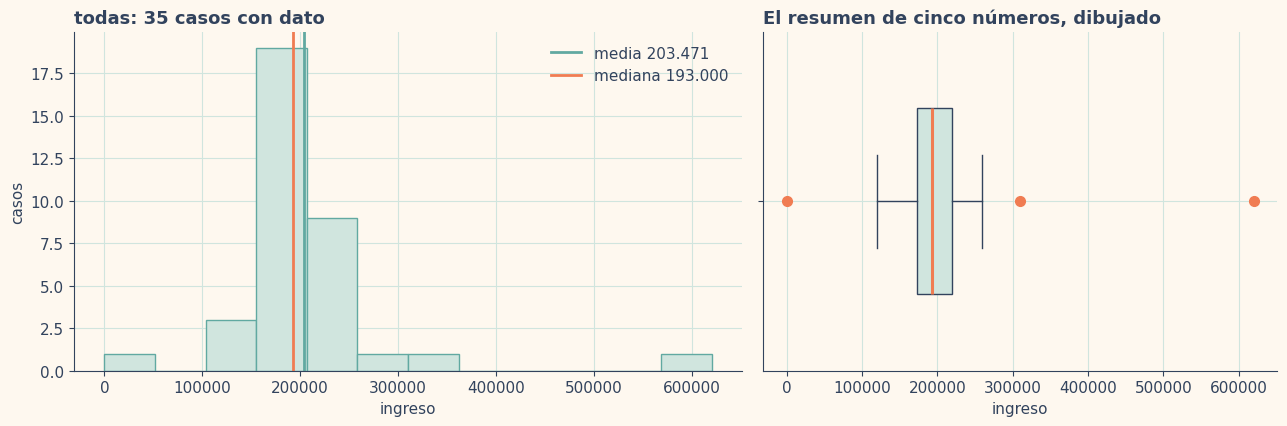

,valor
Casos válidos,35 de 37
Mínimo y máximo,0 y 620.000
Media,203.471
Mediana,193.000
Modo,no tiene: amodal
Q₁ y Q₃,173.500 y 219.500
Desvío standard,86.103
RIC,46.000
Coeficiente de variabilidad,"42,32 %"
Asimetría α₃,"2,8714"


El párrafo, con estos números:

  La variable ingreso de los 35 casos con dato tiene una mediana de 193.000 y una media de 203.471; la diferencia entre las dos y una asimetría de 2,87 indican una distribución estirada hacia los valores altos. La mitad central está entre 173.500 y 219.500, un recorrido de 46.000. Quedan fuera del límite de la regla del 1,5 × RIC: 0, 310.000, 620.000. 2 casos no tienen el dato.

Esto describe a los hogares que se midieron. Afirmar algo sobre los que no se visitaron es inferencia, y empieza en la unidad 5.


In [12]:
#@title La tabla y el párrafo { run: "auto", display-mode: "form" }

variable = "ingreso"  #@param ["ingreso", "personas por hogar"]
localidad = "todas"  #@param ["todas", "Ramallo", "Córdoba", "Concepción"]

columna = "ingreso" if variable == "ingreso" else "personas"
base = hogares if localidad == "todas" else hogares[hogares["localidad"] == localidad]
serie = base[columna].dropna()
x = serie.to_numpy(dtype=float)
d = descriptivo(x)
atipicos = np.sort(x[(x < d["límite inferior 1,5 × RIC"]) | (x > d["límite superior 1,5 × RIC"])])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.hist(x, bins=min(12, max(3, len(np.unique(x)))), color=TEAL_PALIDO, edgecolor=TEAL)
ax1.axvline(d["media"], color=TEAL, linewidth=2, label=f"media {num(d['media'], 0)}")
ax1.axvline(d["mediana"], color=CORAL, linewidth=2, label=f"mediana {num(d['mediana'], 0)}")
ax1.legend(loc="upper right"); ax1.set_xlabel(variable); ax1.set_ylabel("casos")
ax1.set_title(f"{localidad}: {d['casos válidos']} casos con dato")
caja(ax2, [x], [""])
ax2.set_xlabel(variable); ax2.set_title("El resumen de cinco números, dibujado")
plt.tight_layout(); plt.show()

decimales = 4 if variable.startswith("personas") else 0
filas = {
    "Casos válidos": f"{d['casos válidos']} de {len(base)}",
    "Mínimo y máximo": f"{num(d['mínimo'], decimales)} y {num(d['máximo'], decimales)}",
    "Media": num(d["media"], 4 if variable.startswith("personas") else 0),
    "Mediana": num(d["mediana"], decimales),
    "Modo": num(d["modo"], decimales) if not np.isnan(d["modo"]) else "no tiene: amodal",
    "Q₁ y Q₃": f"{num(d['Q₁'], decimales)} y {num(d['Q₃'], decimales)}",
    "Desvío standard": num(d["desvío standard (n)"], 4 if variable.startswith("personas") else 0),
    "RIC": num(d["RIC"], decimales),
    "Coeficiente de variabilidad": num(d["CV (%)"], 2) + " %",
    "Asimetría α₃": num(d["asimetría α₃"], 4),
    "Kurtosis α₄": num(d["kurtosis α₄"], 4),
    "Atípicos por 1,5 × RIC": ", ".join(num(v, decimales) for v in atipicos) if len(atipicos) else "ninguno",
}
display(pd.DataFrame({"valor": filas}))

forma = ("estirada hacia los valores altos" if d["asimetría α₃"] > 0.5 else
         "estirada hacia los valores bajos" if d["asimetría α₃"] < -0.5 else "aproximadamente simétrica")
print("El párrafo, con estos números:")
print()
print(f"  La variable {variable} de los {d['casos válidos']} casos con dato tiene una mediana de "
      f"{num(d['mediana'], decimales)} y una media de {num(d['media'], decimales)}; la diferencia entre "
      f"las dos y una asimetría de {num(d['asimetría α₃'], 2)} indican una distribución {forma}. "
      f"La mitad central está entre {num(d['Q₁'], decimales)} y {num(d['Q₃'], decimales)}, un recorrido "
      f"de {num(d['RIC'], decimales)}. "
      + (f"Quedan fuera del límite de la regla del 1,5 × RIC: {', '.join(num(v, decimales) for v in atipicos)}. "
         if len(atipicos) else "Ningún caso queda fuera del límite de la regla del 1,5 × RIC. ")
      + (f"{len(base) - d['casos válidos']} casos no tienen el dato."
         if len(base) > d["casos válidos"] else "Todos los casos tienen el dato."))
print()
print("Esto describe a los hogares que se midieron. Afirmar algo sobre los que no se visitaron es "
      "inferencia, y empieza en la unidad 5.")


---
## Cierre

Diez formularios, y en todos se puede volver a cambiar algo:

1. La serie de frecuencia, y el denominador que hay que declarar.
2. Los intervalos de clase, el histograma y el precio de agrupar.
3. Las tres medidas de posición, y qué le pasa a cada una con un valor lejano.
4. Los cuartiles por los dos métodos, y los percentiles.
5. El rango, el desvío, el `RIC`, el `CV` y el divisor `n` o `n − 1`.
6. La asimetría, la kurtosis, los coeficientes de Pearson y las cinco convenciones.
7. El z-score contra la regla del `1,5 × RIC`.
8. El gráfico de barras, el orden de las categorías y el eje truncado.
9. El boxplot, sus cinco elementos y la comparación por grupos.
10. El análisis descriptivo completo, con su tabla y su párrafo.

Queda afuera, porque se entiende leyendo, el gráfico de líneas de la sección 7.5: el relevamiento
tiene 45 registros en tres meses, y eso sirve como ejemplo de construcción y no como análisis de una
tendencia.

> **Apunte de la unidad 4:**
> [E8102_Apunte_U4_Analisis_de_Datos.pdf](https://github.com/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-2-distribuciones-y-analisis-de-datos/E8102_Apunte_U4_Analisis_de_Datos.pdf)
